# Projeto Sprint 7

## 1. - Introdução aos Datasets

### 1.1 - Importações

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# leitura pacotes necessários
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

In [ ]:
# leitura tabelas
sql_one = pd.read_csv('/content/drive/MyDrive/bootcamp/SPRINT_7/PROJECT/datasets/moved_project_sql_result_01.csv')
sql_four = pd.read_csv('/content/drive/MyDrive/bootcamp/SPRINT_7/PROJECT/datasets/moved_project_sql_result_04.csv')
sql_seven = pd.read_csv('/content/drive/MyDrive/bootcamp/SPRINT_7/PROJECT/datasets/moved_project_sql_result_07.csv')

### 1.2 - Primeiras impressões

#### 1.2.1 - Primeira tabela

In [ ]:
# exibição primeiras linhas
sql_one.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [ ]:
# descoberta de informações gerais
sql_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [ ]:
# descoberta de detalhes
sql_one.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


A primeira tabela não possui valores nulos, a nomenclatura das colunas está de acordo com os padrões snake_case e não foram encontrados problemas nos dados.

#### 1.2.2 - Segunda tabela

In [ ]:
# exibição primeiras linhas
sql_four.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [ ]:
# descoberta de informações gerais
sql_four.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [ ]:
# descoberta de detalhes
sql_four.describe()

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


A segunda tabela não possui valores nulos, a nomenclatura das colunas está de acordo com os padrões snake_case e não foram encontrados problemas nos dados.

#### 1.2.3 - Terceira tabela

In [ ]:
# exibição primeiras linhas
sql_seven.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [ ]:
# descoberta de informações gerais
sql_seven.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [ ]:
# descoberta de detalhes
sql_seven.describe()

,duration_seconds
count,1068.000000
mean,2071.731273
std,769.461125
min,0.000000
25%,1438.250000
50%,1980.000000
75%,2580.000000
max,7440.000000


A terceira tabela não possui valores nulos, a nomenclatura das colunas está de acordo com os padrões snake_case e algumas alterações nos tipos de dados seriam bem vindas.

## 2. - Pré Processamento dos Dados

### 2.1 - Alteração tipos de dados

In [ ]:
# formato int
sql_seven['duration_seconds'] = sql_seven['duration_seconds'].astype(int)

In [ ]:
# formato datetime
sql_seven['start_ts'] = pd.to_datetime(sql_seven['start_ts'])

### 2.2 - Correção strings

In [ ]:
# aplicação método strip e lower a todas as colunas não numéricas
sql_one['company_name'] = sql_one['company_name'].str.strip().str.lower()
sql_four['dropoff_location_name'] = sql_four['dropoff_location_name'].str.strip().str.lower()
sql_seven['weather_conditions'] = sql_seven['weather_conditions'].str.strip().str.lower()

### 2.3 - Criação nova coluna

In [ ]:
# coluna apenas com horário
sql_seven['start_hour'] = sql_seven['start_ts'].dt.time

In [ ]:
# coluna apenas com data
sql_seven['start_ts'] = sql_seven['start_ts'].dt.date
sql_seven

,start_ts,weather_conditions,duration_seconds,start_hour
0,2017-11-25,good,2410,16:00:00
1,2017-11-25,good,1920,14:00:00
2,2017-11-25,good,1543,12:00:00
3,2017-11-04,good,2512,10:00:00
4,2017-11-11,good,1440,07:00:00
...,...,...,...,...
1063,2017-11-25,good,0,11:00:00
1064,2017-11-11,good,1318,10:00:00
1065,2017-11-11,good,2100,13:00:00
1066,2017-11-11,good,1380,08:00:00


### 2.4 - Validação duplicados

In [ ]:
# primeira tabela
sql_one.duplicated().sum()

np.int64(0)

In [ ]:
# segunda tabela
sql_four.duplicated().sum()

np.int64(0)

In [ ]:
# terceira tabela
sql_seven.duplicated().sum()

np.int64(197)

In [ ]:
# eliminação duplicados
sql_seven.drop_duplicates()

,start_ts,weather_conditions,duration_seconds,start_hour
0,2017-11-25,good,2410,16:00:00
1,2017-11-25,good,1920,14:00:00
2,2017-11-25,good,1543,12:00:00
3,2017-11-04,good,2512,10:00:00
4,2017-11-11,good,1440,07:00:00
...,...,...,...,...
1060,2017-11-04,good,2700,14:00:00
1061,2017-11-18,bad,2186,16:00:00
1063,2017-11-25,good,0,11:00:00
1064,2017-11-11,good,1318,10:00:00


### 2.5 - Validação ausentes

In [ ]:
# primeira tabela
sql_one.isna().sum()

,0
company_name,0
trips_amount,0


In [ ]:
# segunda tabela
sql_four.isna().sum()

,0
dropoff_location_name,0
average_trips,0


In [ ]:
# terceira tabela
sql_seven.isna().sum()

,0
start_ts,0
weather_conditions,0
duration_seconds,0
start_hour,0


## 3. - Análises

### 3.1 - Os 10 principais bairros destino

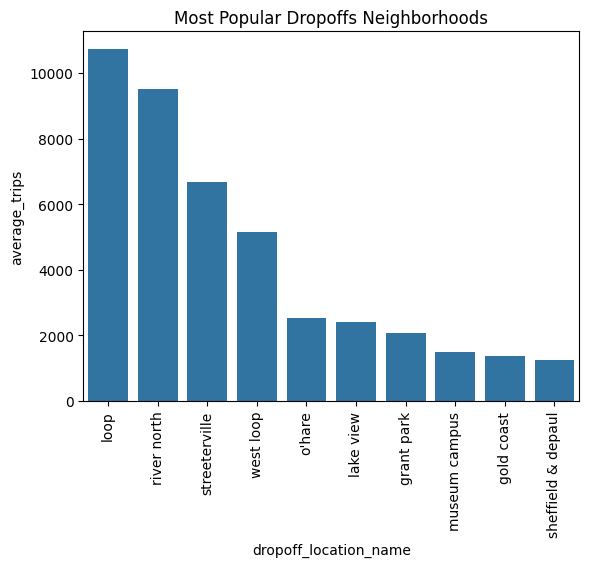

In [ ]:
# filtro top 10 bairros destinos
obj_31 = sql_four.loc[:9]

# criação gráfico
sns.barplot(
    data=obj_31,
    x='dropoff_location_name',
    y='average_trips'
    )
plt.title('Most Popular Dropoffs Neighborhoods')
plt.xticks(rotation=90)

plt.show()

Os bairros Loop e River North são disparadamente os mais visitados, seguidos por Streeterville e West Loop.

Enquanto os demais seguem bem nivelados.

### 3.2 - As 10 principais empresas de táxi

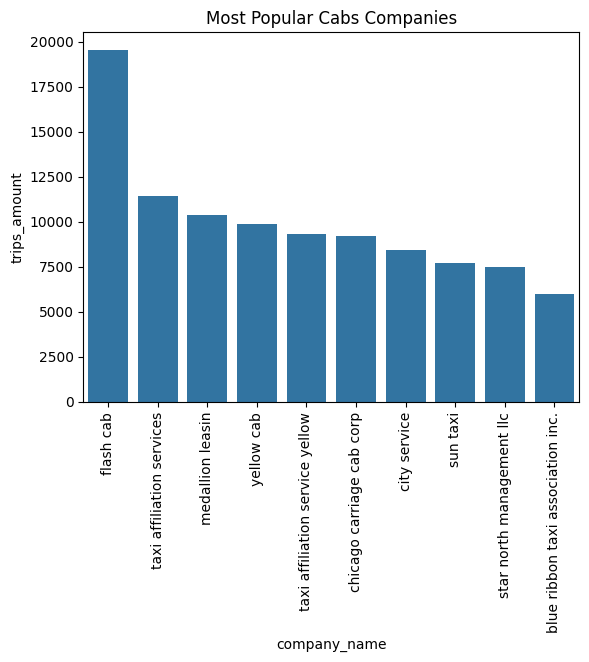

In [ ]:
# filtro top 10 empresas
obj_32 = sql_one.loc[:9]

# criação gráfico
sns.barplot(
    data=obj_32,
    x='company_name',
    y='trips_amount'
    )
plt.title('Most Popular Cabs Companies')
plt.xticks(rotation=90)
plt.show()

Com ampla vantagem, a Flash Cab lidera como a companhia de táxis mais popular.

Enquanto as demais tem os resultados bem equiparados.

## 4 - Teste de Hipóteses

### 4.1 - A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos?

In [ ]:
# correção tipo de dado
sql_seven['start_ts'] = pd.to_datetime(sql_seven['start_ts'])

In [ ]:
# nova coluna com dias
sql_seven['day'] = sql_seven['start_ts'].dt.day

,start_ts,weather_conditions,duration_seconds,start_hour,day
0,2017-11-25,good,2410,16:00:00,25
1,2017-11-25,good,1920,14:00:00,25
2,2017-11-25,good,1543,12:00:00,25
3,2017-11-04,good,2512,10:00:00,4
4,2017-11-11,good,1440,07:00:00,11
...,...,...,...,...,...
1063,2017-11-25,good,0,11:00:00,25
1064,2017-11-11,good,1318,10:00:00,11
1065,2017-11-11,good,2100,13:00:00,11
1066,2017-11-11,good,1380,08:00:00,11


In [ ]:
# filtro sabádos e clima ruim
bad_saturday = sql_seven[
    sql_seven['day'].isin([4, 11, 18, 25])
    &
    (sql_seven['weather_conditions'] == 'bad')]

In [ ]:
# filtro sabádos e clima bom
good_saturday = sql_seven[
    sql_seven['day'].isin([4, 11, 18, 25])
    &
    (sql_seven['weather_conditions'] == 'good')]

In [ ]:
# isolando coluna
good_minutes = good_saturday['duration_seconds'] / 60
bad_minutes = bad_saturday['duration_seconds'] / 60

# teste variância
print(f'Variância do primeiro objeto: {good_minutes.var()}')
print(f'Variância do segundo objeto: {bad_minutes.var()}')

# definição alpha
alpha = 0.05

# teste estatístico bicaudal
results = st.ttest_ind(good_minutes, bad_minutes, equal_var=False)

# hipótese nula e alternativa
if results.pvalue < alpha:
  print('Hipótese nula rejeitada: a duração média da viagem em circunstâncias chuvosas aos sabádos são diferentes se comparado ao mesmo dia em circunstâncias normais.')
else:
  print('Não se pode rejeitar a hipótese nula: a duração média da viagem em circunstâncias chuvosas aos sabádos são iguais se comparado ao mesmo dia circunstâncias normais.')


Variância do primeiro objeto: 160.10611380264154
Variância do segundo objeto: 144.52613500068975
Hipótese nula rejeitada: a duração média da viagem em circunstâncias chuvosas aos sabádos parece diferente se comparado ao mesmo dia em circunstâncias normais.


# 5. - Conclusão

Com base na análise dos dados fornecidos pela empresa Zuber, nova empresa de compartilhamento de caronas que está sendo lançada em Chicago, foi possível identificar os bairros de Chicago mais visitados em Novembro de 2017, sendo eles: Loop, Rivernorth, Streeterville, West Loop e O'Hare.

Podemos inferir que as empresas de táxi com maior número de viagens de 15 a 16 de novembro de 2017 foram: Flash Cab, Taxi Affiliation Services, Medallion Leasin, Yellow Cab e Taxi Affiliation Services Yellow.

A hipótese de que a duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos foi confirmada, com base no teste t realizado para comparar a duração média dos passeios entre sábados com clima normal e sábados chuvosos, encontramos um p-valor inferior ao nível de significância de 0,05. Isso indica evidência estatística suficiente para rejeitar a hipótese nula de que as médias são iguais.